## Uncertainties in position reconstruction with the XENON1T Detector

XENON1T was a dark matter detector that I worked on for my PhD thesis. One of our data analysis problems was reconstructing the positions of particle interactions in the detector.

In this notebook you're going to train a neural network to do that reconstruction.

### Set up simulator

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import configparser
from scipy import stats

This downloads the detector configuration, specifically, the positions of the light sensors (photomultipliers or PMTs).

In [2]:
!curl -O https://raw.githubusercontent.com/XENON1T/pax/refs/heads/master/pax/config/XENON1T.ini
config = configparser.ConfigParser()
config.read('XENON1T.ini')
pmt_config = eval(config['DEFAULT']['pmts'])
pmt_positions = np.array([(x['position']['x'], x['position']['y'])
                           for x in pmt_config if x.get('array', '') == 'top'])
tpc_radius = 47.9

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  303k  100  303k    0     0   757k      0 --:--:-- --:--:-- --:--:--  756k


Set up a simple simulator to create fake observed XENON1T patterns. We have a rather more intricate simulation, but this is enough for this exercise.

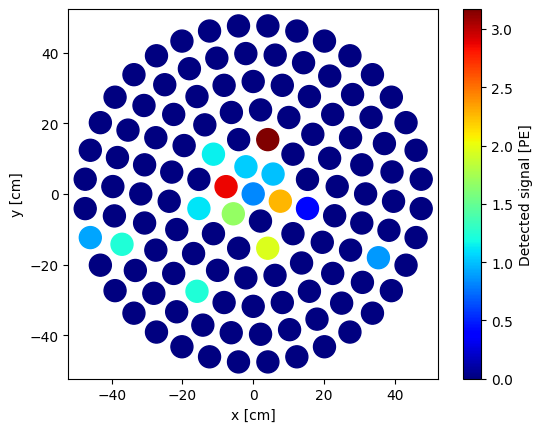

In [5]:
def mean_response(xy):
    """Return normalized mean response of PMTs to light emission at xy"""
    a = -2.7e-5
    b = 3.6e-3
    i0 = 0.290
    d = 12.13
    p = 2.35
    # Compute distance from xy to pmt position
    # xy has shape (positions, 2)
    # pmt_positions has shape (pmts, 2)
    # Output should have shape (positions, pmts)
    rho = np.linalg.norm(xy[:, None, :] - pmt_positions[None, :, :], axis=2)
    raw_lce = i0 * (1-b) / (1 + (rho/d)**2)**p + a * rho + b
    # Normalize to 1
    return raw_lce / np.sum(raw_lce, axis=1)[:, None]

def simulate_signal(xy, photons=10_000):
    """Simulate a signal where an average number of photons are detected by PMTs at xy"""
    lce = mean_response(xy)
    # Random photon detection
    photons_detected = np.random.poisson(photons * lce)
    # Double photoelectron emission
    pe_detected = photons_detected + np.random.binomial(photons_detected, 0.2)
    # Gaussian smearing
    return np.random.normal(pe_detected, 0.3 * np.sqrt(pe_detected))

def plot_signal(signal):
    """Plot the signal detected by the PMTs"""
    plt.scatter(*pmt_positions.T, c=signal, cmap='jet', s=250, vmin=0)
    plt.colorbar(label='Detected signal [PE]')
    plt.gca().set_aspect('equal')
    plt.xlabel('x [cm]')
    plt.ylabel('y [cm]')

plot_signal(simulate_signal(np.array([[0, 0]]), photons=30)[0])

The plot above shows the signal we detect in our PMTs for a very small signal (30 photons on average) from the center of the detector.

# Simulate training data

In [ ]:
def simulate_positions(n):
    """Return positions uniformly distributed in the TPC"""
    r2 = np.random.uniform(0, tpc_radius**2, size=n)
    theta = np.random.uniform(0, 2*np.pi, size=n)
    return np.sqrt(r2)[:,None] * np.column_stack((np.cos(theta), np.sin(theta)))

def simulate_s2s(n, photons):
    y = simulate_positions(n)
    return simulate_signal(y, photons=photons), y

X_train, y_train = simulate_s2s(100_000, 30)
X_val, y_val = simulate_s2s(1000, 30)

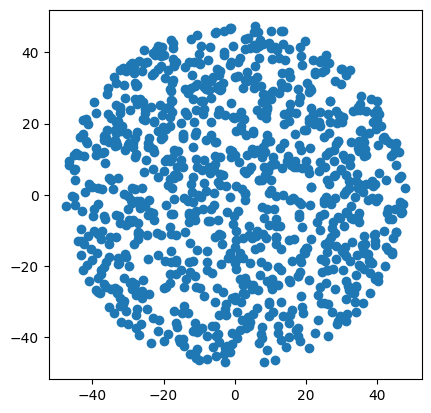

In [ ]:
# Scatter y_val as check on homogeneity
plt.scatter(*y_val.T)
plt.gca().set_aspect('equal')

# Train basic model

In [ ]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import keras
ops = keras.ops

def rmse(y_true, y_pred):
    """Return root mean square error between y_true and y_pred"""
    return ops.sqrt(ops.mean(ops.square(y_pred - y_true)))

In [ ]:
class TestTimeDropout(keras.layers.Dropout):
    def call(self, inputs, training=False):
        return super().call(inputs, training=True)

def make_model(p_dropout, n_outputs=2, test_time_dropout=False):
    dropout = TestTimeDropout if test_time_dropout else keras.layers.Dropout
    return keras.models.Sequential([
        keras.layers.Input(shape=(len(pmt_positions),)),

        keras.layers.Normalization(
            axis=1,
            mean=np.mean(X_train, axis=0),
            variance=np.var(X_train, axis=0),
            input_shape=(len(pmt_positions),)),

        keras.layers.Dense(64, activation='relu', input_shape=(len(pmt_positions),)),
        keras.layers.BatchNormalization(),
        dropout(p_dropout),

        keras.layers.Dense(64, activation='relu'),
        keras.layers.BatchNormalization(),
        dropout(p_dropout),

        keras.layers.Dense(64, activation='relu'),
        keras.layers.BatchNormalization(),
        dropout(p_dropout),

        keras.layers.Dense(n_outputs)
    ])

In [ ]:
batch_size = 1024
epochs = 10

model = make_model(0.)
model.compile(optimizer='adam', loss='mse', metrics=[rmse])
model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_val, y_val))

Epoch 1/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 177.7269 - rmse: 12.3551 - val_loss: 27.8676 - val_rmse: 5.2790
Epoch 2/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 11.8510 - rmse: 3.3691 - val_loss: 6.8050 - val_rmse: 2.6086
Epoch 3/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 6.9717 - rmse: 2.6395 - val_loss: 5.9078 - val_rmse: 2.4306
Epoch 4/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 6.4076 - rmse: 2.5288 - val_loss: 5.5679 - val_rmse: 2.3596
Epoch 5/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 5.9621 - rmse: 2.4396 - val_loss: 5.3888 - val_rmse: 2.3214
Epoch 6/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 5.8699 - rmse: 2.4228 - val_loss: 5.1577 - val_rmse: 2.2710
Epoch 7/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 5.7630 - rmse: 2.4020 - val_loss: 5.0549 - val_rmse: 2.2483
Epoch 8/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 5.7143 - rmse: 2.3880 - val_loss: 4.9653 - val_rmse: 2.2283
Epoch 9/10
245/245 ━━━━━━━━

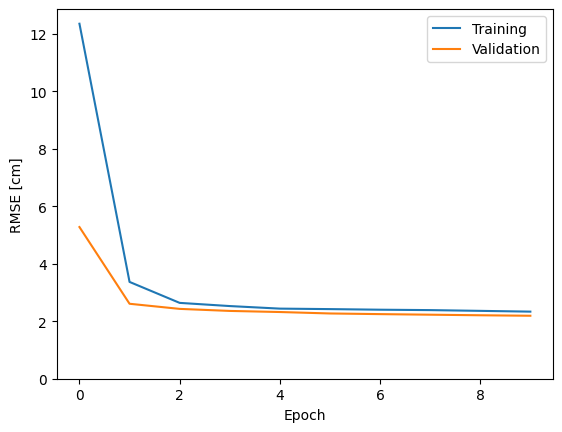

In [ ]:
# Plot rmse history
plt.plot(model.history.history['rmse'], label='Training')
plt.plot(model.history.history['val_rmse'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('RMSE [cm]')
plt.ylim(0, None)
plt.legend()

## Output uncertainty as well

In [ ]:
def split_output(y):
    """Returns prediction, uncertainty"""
    return y[:, :2], y[:, 2:]

def rmse_with_uncertainty_loss(y_true, output):
    y_pred, log_sigma = split_output(output)
    log_sigma = ops.clip(log_sigma, -5, 5)
    sigma = ops.exp(log_sigma)
    loss = ((y_pred - y_true)/sigma)**2 + 2 * sigma
    return ops.mean(loss, axis=-1)

def bare_rmse(y_true, y_pred):
    return rmse(y_true, split_output(y_pred)[0])

In [ ]:
model = make_model(0., n_outputs=4)

# Bit of prefitting at high learning rate to make loss predictions sane
model.compile(optimizer=keras.optimizers.Adam(0.05),
              loss=rmse_with_uncertainty_loss, metrics=[bare_rmse])
history = model.fit(X_train, y_train, batch_size=batch_size, epochs=2, validation_data=(X_val, y_val))

# Actual fitting
model.compile(optimizer='adam',
              loss=rmse_with_uncertainty_loss, metrics=[bare_rmse])
history = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_val, y_val))


Epoch 1/2
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - bare_rmse: 23.6163 - loss: 1787.8499 - val_bare_rmse: 23.9241 - val_loss: 68.1036
Epoch 2/2
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - bare_rmse: 23.6438 - loss: 49.0325 - val_bare_rmse: 23.9019 - val_loss: 42.6825
Epoch 1/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - bare_rmse: 20.8207 - loss: 23.3864 - val_bare_rmse: 17.1075 - val_loss: 16.7094
Epoch 2/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - bare_rmse: 13.3799 - loss: 13.3843 - val_bare_rmse: 8.7947 - val_loss: 9.9551
Epoch 3/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - bare_rmse: 5.4321 - loss: 7.9349 - val_bare_rmse: 3.4244 - val_loss: 6.7305
Epoch 4/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - bare_rmse: 3.1563 - loss: 6.3527 - val_bare_rmse: 2.8502 - val_loss: 5.9354
Epoch 5/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - bare_rmse: 2.8441 - loss: 5.9688 - val_bare_rmse: 2.6612 - val_loss: 5.6799
Epoch 6/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - bare_rmse: 2.7

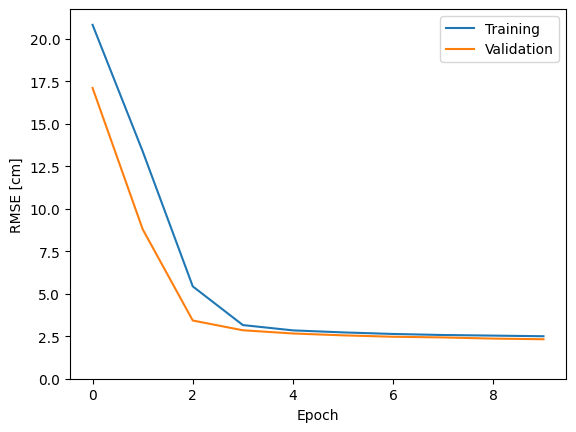

In [ ]:
# Plot rmse history
plt.plot(history.history['bare_rmse'], label='Training')
plt.plot(history.history['val_bare_rmse'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('RMSE [cm]')
plt.ylim(0, None)
plt.legend()

### Are uncertainties OK?

In [ ]:
y_true = y_val
raw = model.predict(X_val, verbose=0)
y_pred, log_sigma = split_output(raw)
log_sigma = np.clip(log_sigma, -5, 5)
sigma = np.exp(log_sigma)

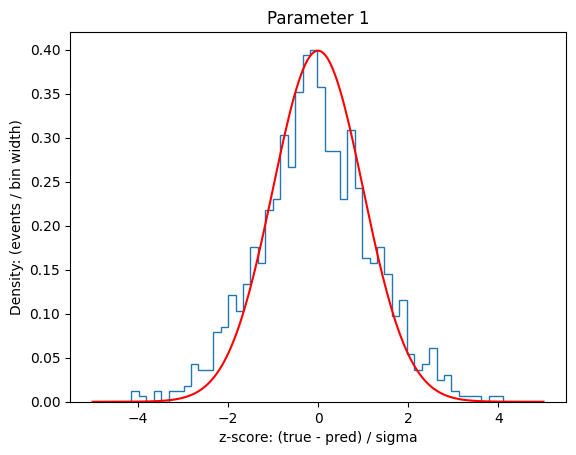

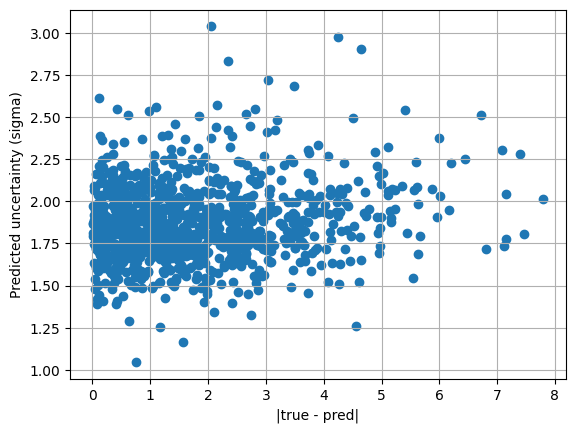

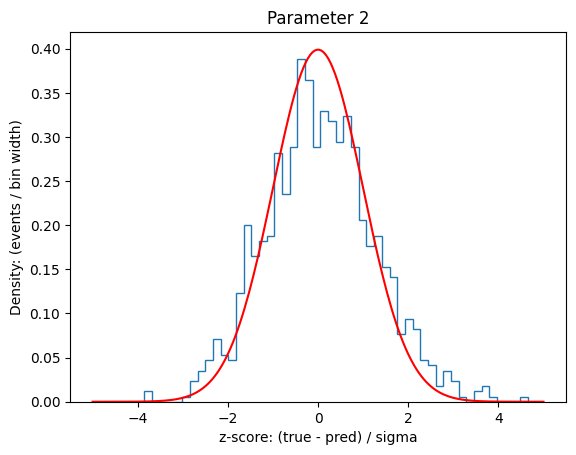

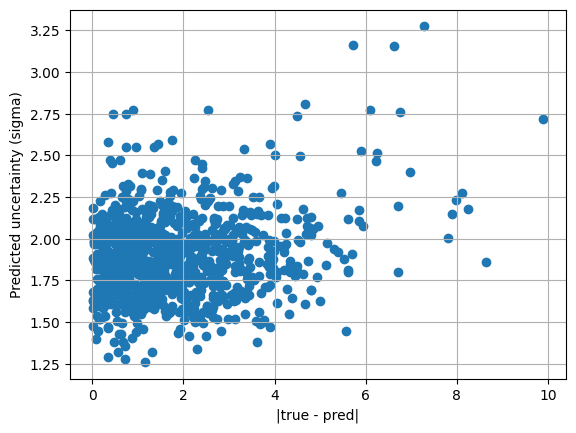

In [ ]:
zs = (y_true - y_pred) / sigma

for par_i in range(2):
    plt.hist(zs[:,par_i], bins=50, density='true', histtype='step')
    _x = np.linspace(-5, 5, 200)
    plt.plot(_x, stats.norm.pdf(_x), label='N(0,1)', c='r')
    plt.xlabel('z-score: (true - pred) / sigma')
    plt.ylabel('Density: (events / bin width)')
    plt.title(f"Parameter {par_i+1}")
    plt.show()

    _x = np.abs(y_true[:, par_i] - y_pred[:, par_i])
    _y = sigma[:, par_i]
    plt.scatter(_x, _y)

    plt.xlabel('|true - pred|')
    plt.ylabel('Predicted uncertainty (sigma)')
    plt.grid()
    plt.show()

## Estimating error from variance with test-time dropout

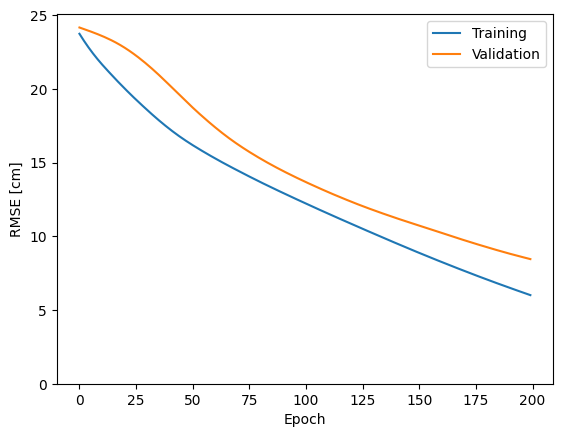

In [ ]:
# Make a smaller training set, to see if we can overfit
X_train, y_train = simulate_s2s(256, 30)

p_dropout = 0.  # We want to overfit

model = make_model(p_dropout, n_outputs=2, test_time_dropout=True)
model.compile(optimizer='adam', loss='mse', metrics=[rmse])
history = model.fit(
    X_train, y_train,
    batch_size=batch_size, epochs=20 * epochs,
    verbose=0,
    validation_data=(X_val, y_val))

# Plot history
plt.plot(history.history['rmse'], label='Training')
plt.plot(history.history['val_rmse'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('RMSE [cm]')
plt.ylim(0, None)
plt.legend()

In [ ]:
# Compare train and val loss _without_ dropout, to verify overtraining
for x, y, dsetname in ((X_train, y_train, 'train'), (X_val, y_val, 'val')):
    _, rmse_eval = model.evaluate(x, y, batch_size=batch_size)
    print(f'RMSE on {dsetname}: {rmse_eval:.2f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 40.4138 - rmse: 6.3572


RMSE on train: 6.36
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 71.4102 - rmse: 8.4505
RMSE on val: 8.45


In [ ]:
# Make many new predictions with new model
n_trials = 100
y_preds = np.stack([
    model.predict(X_val, batch_size=batch_size, verbose=0)
    for _ in range(n_trials)])

# Get mean and std of predictions across n_trials
y_pred = np.mean(y_preds, axis=0)
unc = np.std(y_preds, axis=0)

In [ ]:
np.mean(np.linalg.norm(unc, axis=-1))

np.float32(1.611016e-05)

This only illustrates the rough idea from https://arxiv.org/abs/1506.02142 (Gal & Garmani).

The fact that the average uncertainy roughly agrees with the error here is because I adjusted the dropout probability to make it so.

In general, these uncertainties need some kind of calibration. That doesn't mean they are useless: perhaps the uncertainty can vary a lot with the input. Then after we calibrate the average uncertainty to be correct, the network tells us how uncertain each individual prediction is.